In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]  = (8, 5)
df = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')
print("Missing values per column before cleaning:")
print(df.isnull().sum())

Missing values per column before cleaning:
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64


Missing values after target cleaning:
TV       0
Sales    0
dtype: int64


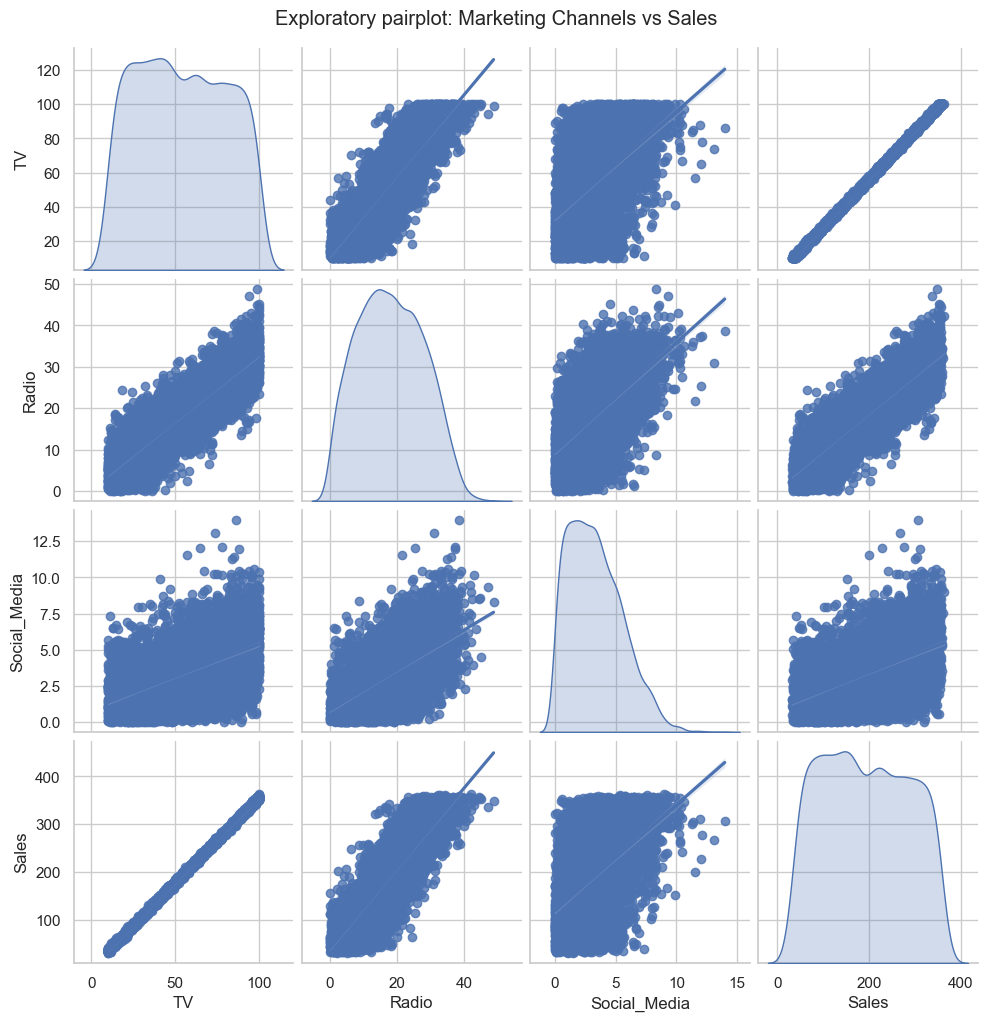

In [2]:
df_clean = df.dropna(subset=['TV', 'Sales']).copy()
print("Missing values after target cleaning:")
print(df_clean[['TV', 'Sales']].isnull().sum())
sns.pairplot(df_clean, kind='reg', diag_kind='kde')
plt.suptitle("Exploratory pairplot: Marketing Channels vs Sales", y=1.02)
plt.show()

In [4]:
ols_formula = "Sales ~ TV"
model = ols(formula=ols_formula, data=df_clean)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        03:51:13   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1263      0.101     -1.257      0.2

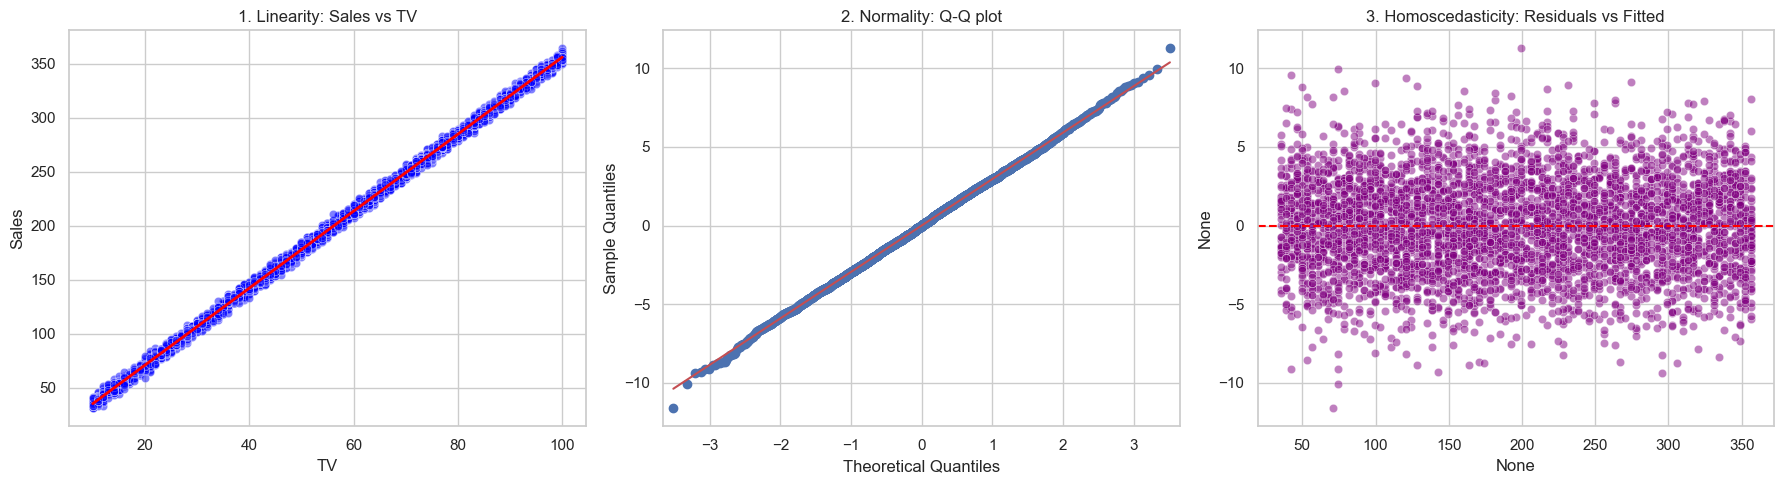

In [6]:
fitted_vals = results.predict(df_clean['TV'])
resids = results.resid
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x=df_clean['TV'], y=df_clean['Sales'], ax=axes[0], color='blue', alpha=0.5)
sns.lineplot(x=df_clean['TV'], y=fitted_vals, ax=axes[0], color='red', linewidth=2)
axes[0].set_title("1. Linearity: Sales vs TV")
sm.qqplot(resids, line='s', ax=axes[1])
axes[1].set_title("2. Normality: Q-Q plot")
sns.scatterplot(x=fitted_vals, y=resids, ax=axes[2], color='purple', alpha=0.5)
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_title("3. Homoscedasticity: Residuals vs Fitted")
plt.tight_layout()
plt.show()

## Visual Verification of Regression Assumptions
* **Linearity**: The direct scatterplot exhibits an explicit linear relationship; the observations align directly along the red operational regression line.
* **Normality ( Q-Q Plot)**: The residual metrics fall directly along the 45-degree standardized trend line, verifying that the model error terms are normally distributed.
* **Homoscedasticity**: The residual distribution pattern shows stable, uniform varaince across all predicted values along the base line, satisfying homoscedasticity requirements.

